In [31]:
import os
import numpy as np
import pandas as pd
import librosa
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, Dropout, Dense, Concatenate, GlobalAveragePooling1D

In [32]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d /kaggle/working/ravdess_audio_data/


Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /kaggle/working/ravdess_audio_data/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [33]:
dataset_path="/kaggle/working/ravdess_audio_data"

paths = []
emotions = []

emotion_dict = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            emotion = emotion_dict[file.split("-")[2]]
            path = os.path.join(root, file)

            paths.append(path)
            emotions.append(emotion)

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = emotions

print(df.head())
print("Total samples:", len(df))

                                                path  emotion
0  /kaggle/working/ravdess_audio_data/Actor_19/03...  disgust
1  /kaggle/working/ravdess_audio_data/Actor_19/03...    angry
2  /kaggle/working/ravdess_audio_data/Actor_19/03...  fearful
3  /kaggle/working/ravdess_audio_data/Actor_19/03...      sad
4  /kaggle/working/ravdess_audio_data/Actor_19/03...    angry
Total samples: 2880


In [ ]:
def _compute_features(y, sr=22050):
    hop_length = int(0.010 * sr)
    n_fft = int(0.025 * sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40,
                                hop_length=hop_length, n_fft=n_fft).T

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                         hop_length=hop_length, n_fft=n_fft)
    mel_db = librosa.power_to_db(mel, ref=np.max).T

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12,
                                         hop_length=hop_length, n_fft=n_fft).T

    #normalization
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)
    chroma = (chroma - np.mean(chroma)) / (np.std(chroma) + 1e-6)

    return mfcc, mel_db, chroma

In [35]:
X_mfcc, X_mel, X_chroma, y_labels = [], [], [], []

for path, emotion in zip(df.path, df.emotion):
    try:
        y, sr = librosa.load(path, sr=22050, duration=4.0)

        # padding signal if short
        if len(y) < sr * 4:
            y = np.pad(y, (0, int(sr*4) - len(y)))

        mfcc, mel, chroma = _compute_features(y, sr)

        X_mfcc.append(mfcc)
        X_mel.append(mel)
        X_chroma.append(chroma)
        y_labels.append(emotion)

    except:
        pass

print("Done extracting original features")

Done extracting original features


In [36]:
X_mfcc = pad_sequences(X_mfcc, maxlen=300, padding='post', truncating='post')
X_mel = pad_sequences(X_mel, maxlen=300, padding='post', truncating='post')
X_chroma = pad_sequences(X_chroma, maxlen=300, padding='post', truncating='post')

In [37]:
le = LabelEncoder()
le.fit(list(emotion_dict.values()))

y_encoded = le.transform(y_labels)
y = to_categorical(y_encoded, num_classes=8)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_mfcc, X_temp_mfcc, \
X_train_mel, X_temp_mel, \
X_train_chroma, X_temp_chroma, \
y_train, y_temp = train_test_split(
    X_mfcc, X_mel, X_chroma, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
X_val_mfcc, X_test_mfcc, \
X_val_mel, X_test_mel, \
X_val_chroma, X_test_chroma, \
y_val, y_test = train_test_split(
    X_temp_mfcc, X_temp_mel, X_temp_chroma, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [39]:
def add_noise(y):
    return y + 0.005 * np.random.randn(len(y))

def shift(y, sr):
    shift_range = int(sr * 0.2)
    shift = random.randint(-shift_range, shift_range)
    return np.roll(y, shift)

In [40]:
X_mfcc_aug, X_mel_aug, X_chroma_aug, y_aug = [], [], [], []

for path, emotion in zip(df.path, df.emotion):
    try:
        y_audio, sr = librosa.load(path, sr=22050, duration=4.0)

        for aug in [add_noise(y_audio), shift(y_audio, sr)]:
            mfcc, mel, chroma = _compute_features(aug, sr)

            X_mfcc_aug.append(mfcc)
            X_mel_aug.append(mel)
            X_chroma_aug.append(chroma)
            y_aug.append(emotion)

    except:
        pass

# pad
X_mfcc_aug = pad_sequences(X_mfcc_aug, maxlen=300)
X_mel_aug = pad_sequences(X_mel_aug, maxlen=300)
X_chroma_aug = pad_sequences(X_chroma_aug, maxlen=300)

# encode
y_aug_encoded = le.transform(y_aug)
y_aug = to_categorical(y_aug_encoded, num_classes=8)

In [41]:
X_train_mfcc = np.concatenate([X_train_mfcc, X_mfcc_aug])
X_train_mel = np.concatenate([X_train_mel, X_mel_aug])
X_train_chroma = np.concatenate([X_train_chroma, X_chroma_aug])
y_train = np.concatenate([y_train, y_aug])

In [ ]:
def build_model(mfcc_shape, mel_shape, chroma_shape, num_classes=8):
    input_mfcc = Input(shape=mfcc_shape, name="mfcc_input")
    input_mel = Input(shape=mel_shape, name="mel_input")
    input_chroma = Input(shape=chroma_shape, name="chroma_input")

    def create_cnn_branch(x, filters, kernel_size, pool_size, dropout_rate):
        x = Conv1D(filters, kernel_size, padding='same')(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)
        x = MaxPooling1D(pool_size=pool_size)(x)
        x = Dropout(dropout_rate)(x)
        return x

    # MFCC branch
    m = create_cnn_branch(input_mfcc, 128, 5, 2, 0.4)
    m = create_cnn_branch(m, 64, 3, 2, 0.3)
    m = create_cnn_branch(m, 32, 3, 2, 0.2)

    # Mel branch
    s = create_cnn_branch(input_mel, 128, 5, 2, 0.4)
    s = create_cnn_branch(s, 64, 3, 2, 0.3)
    s = create_cnn_branch(s, 32, 3, 2, 0.2)

    # Chroma branch
    c = create_cnn_branch(input_chroma, 128, 5, 2, 0.4)
    c = create_cnn_branch(c, 64, 3, 2, 0.3)
    c = create_cnn_branch(c, 32, 3, 2, 0.2)

    m_pool = GlobalAveragePooling1D()(m)
    s_pool = GlobalAveragePooling1D()(s)
    c_pool = GlobalAveragePooling1D()(c)

    # Merge branches
    merged = Concatenate()([m_pool, s_pool, c_pool])

    # Fully Connected Layers
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.4)(merged)

    output = Dense(num_classes, activation='softmax')(merged)

    model = Model(inputs=[input_mfcc, input_mel, input_chroma], outputs=output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001) # Increased the Learning Rate a bit to get out of the valley
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

model = build_model(
    mfcc_shape=(300, 40),
    mel_shape=(300, 128),
    chroma_shape=(300, 12),
    num_classes=8
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 300, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_input           │ (None, 300, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_input        │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 300, 128)  │     25,728 │ mfcc_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 300, 128)  │     82,048 │ mel_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 300, 128)  │      7,808 │ chroma_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 150, 128)  │          0 │ re_lu_9[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 150, 128)  │          0 │ re_lu_12[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 150, 128)  │          0 │ re_lu_15[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 150, 128)  │          0 │ max_pooling1d_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 150, 128)  │          0 │ max_pooling1d_12… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 150, 128)  │          0 │ max_pooling1d_15… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 150, 64)   │     24,640 │ dropout_10[0][0]

 Total params: 224,168 (875.66 KB)

 Trainable params: 222,824 (870.41 KB)

 Non-trainable params: 1,344 (5.25 KB)

In [43]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    factor=0.5,
    patience=5
)

In [44]:
history = model.fit(
    [X_train_mfcc, X_train_mel, X_train_chroma],
    y_train,
    validation_data=([X_val_mfcc, X_val_mel, X_val_chroma], y_val),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.1618 - loss: 2.1464 - val_accuracy: 0.2292 - val_loss: 2.0096 - learning_rate: 1.0000e-04
Epoch 2/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2498 - loss: 1.9235 - val_accuracy: 0.3565 - val_loss: 1.8564 - learning_rate: 1.0000e-04
Epoch 3/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3110 - loss: 1.8128 - val_accuracy: 0.3681 - val_loss: 1.7748 - learning_rate: 1.0000e-04
Epoch 4/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3452 - loss: 1.7330 - val_accuracy: 0.4282 - val_loss: 1.6797 - learning_rate: 1.0000e-04
Epoch 5/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3717 - loss: 1.6615 - val_accuracy: 0.4259 - val_loss: 1.6373 - learning_rate: 1.0000e-04
Epoch 6/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4074 - loss: 1.6114 - val_accuracy: 0.4861 - val_loss: 1.5802 - learning_rate: 1.0000e-04
Epoch 7/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/st

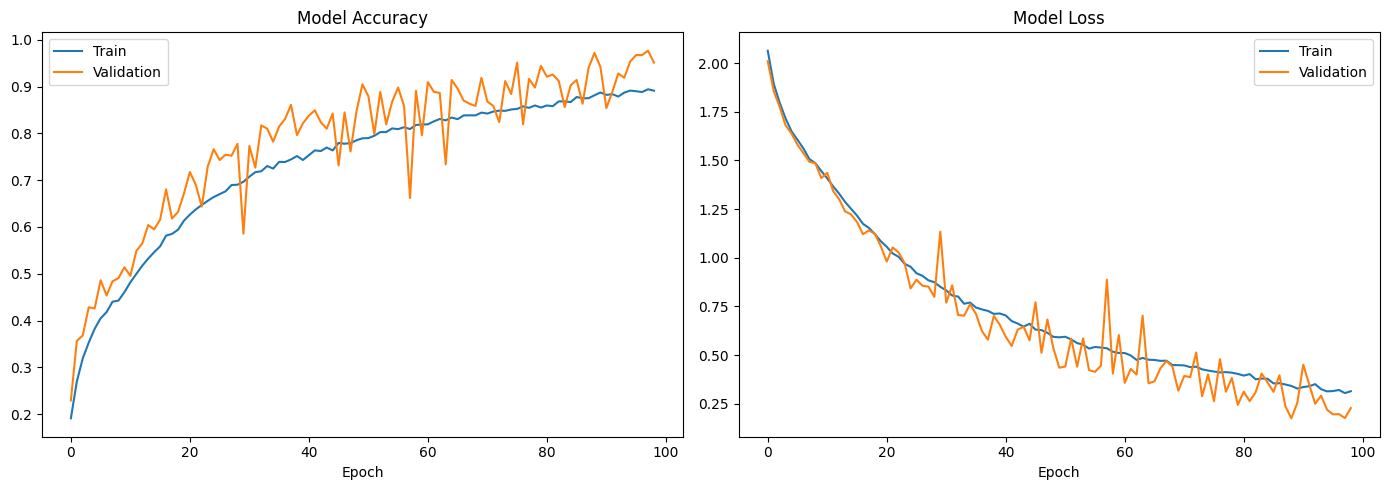

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [46]:
test_loss, test_acc = model.evaluate(
    [X_test_mfcc, X_test_mel, X_test_chroma],
    y_test
)

print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.1540
Test Accuracy: 0.9861111044883728


In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict([X_test_mfcc, X_test_mel, X_test_chroma])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        58
           1       0.95      1.00      0.97        57
           2       0.98      1.00      0.99        58
           3       1.00      0.98      0.99        58
           4       1.00      0.98      0.99        58
           5       0.96      0.93      0.95        29
           6       0.98      0.98      0.98        57
           7       1.00      1.00      1.00        57

    accuracy                           0.99       432
   macro avg       0.98      0.98      0.98       432
weighted avg       0.99      0.99      0.99       432



In [50]:
model.save("emotion_model_enhanced.h5")

In [51]:
import pickle

with open("label_encoder_enhanced.pkl", "wb") as f:
    pickle.dump(le, f)